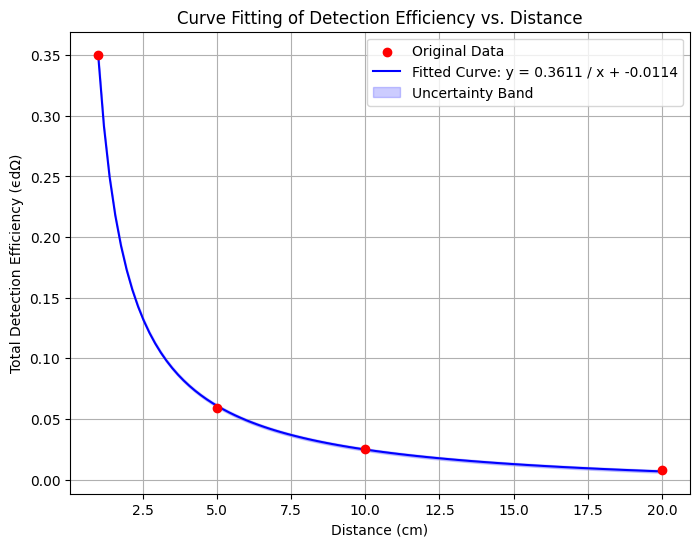

Fitted parameters:
  a = 0.3611 ± 0.0021
  b = -0.0114 ± 0.0011


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Given data
h = np.array([1, 5, 10, 20])  # Distance in cm
epsilon = np.array([0.35, 0.059, 0.025, 0.008])  # Detection efficiency

# Define the updated model function: y = a / x + b
def model(x, a, b):
    return a / x + b

# Perform the curve fitting
params, covariance = curve_fit(model, h, epsilon)

# Get the fitted parameters and their uncertainties
a, b = params
sigma_a, sigma_b = np.sqrt(np.diag(covariance))

# Generate fitted data for plotting
h_fit = np.linspace(min(h), max(h), 100)  # Generate a range of h values
epsilon_fit = model(h_fit, *params)  # Corresponding epsilon values from the model

# Calculate the uncertainty in y (epsilon_fit) using error propagation
def calculate_uncertainty(x, a, b, sigma_a, sigma_b):
    term_a = (1 / x * sigma_a)**2  # Derivative of a / x is -a / x^2
    term_b = (sigma_b)**2  # Uncertainty in b does not depend on x
    return np.sqrt(term_a + term_b)

epsilon_uncertainty = calculate_uncertainty(h_fit, a, b, sigma_a, sigma_b)

# Plotting the original data, fitted curve, and uncertainties
plt.figure(figsize=(8, 6))
plt.scatter(h, epsilon, color='red', label='Original Data', zorder=5)
plt.plot(h_fit, epsilon_fit, label=f'Fitted Curve: y = {a:.4f} / x + {b:.4f}', color='blue')
plt.fill_between(h_fit, epsilon_fit - epsilon_uncertainty, epsilon_fit + epsilon_uncertainty,
                 color='blue', alpha=0.2, label='Uncertainty Band')
plt.xlabel('Distance (cm)')
plt.ylabel('Total Detection Efficiency (ϵdΩ)')
plt.title('Curve Fitting of Detection Efficiency vs. Distance')
plt.legend()
plt.grid(True)
plt.show()

# Print the results
print(f"Fitted parameters:")
print(f"  a = {a:.4f} ± {sigma_a:.4f}")
print(f"  b = {b:.4f} ± {sigma_b:.4f}")